<a href="https://colab.research.google.com/github/giuliacenni-dns/MindCare/blob/main/Draft%20code%20MindReading_Report1_Template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install nilearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 54.5 MB/s eta 0:00:00


# Structural Imaging Assignment
For this assignment, you will work with MRI data from approximately 900 participants from the Amsterdam Open MRI Collection (AOMIC). The dataset is described in detail here:

Snoek, L., van der Miesen, M.M., Beemsterboer, T. et al. The Amsterdam Open MRI Collection, a set of multimodal MRI datasets for individual difference analyses. Sci Data 8, 85 (2021). https://doi.org/10.1038/s41597-021-00870-6

FreeSurfer preprocessing has already been completed. You will receive:

- A CSV table with FreeSurfer-derived measures (cortical thickness, surface area, curvature, subcortical volumes)
- A table with demographic information (age, biological sex)
- A data dictionary explaining each column

### Your Task
Build a classification model to predict biological sex from brain structure. Specifically:
- Identify which brain measures contribute most to classification
- Quantify effect sizes and classification performance
- Characterise the degree of overlap between groups
- Discuss what your findings reveal about sex differences in brain structure

For this assignment, you will use logistic regression to classify sex from brain structure. Logistic regression is appropriate for binary classification, computationally efficient, and provides interpretable coefficients indicating which features contribute most to classification.

## Instructions
You can use this template to complete your analysis. Feel free to modify the code as needed, but make sure to include all required steps in your final report. The intended structure and grading criteria for this assignment are described on Canvas. You can also refer to the notebooks from the lab practicals, especially Lab 4 on predicting age from brain structure.

You may run this notebook locally or via Google Colab. If you run it locally, make sure to install the required packages (e.g., pandas, scikit-learn, nilearn) in your Python environment. If you run it on Colab, you can install the packages using the `pip` command. The command to install nilearn is included in the first code cell of this notebook.

You may use Generative AI tools (e.g., ChatGPT, Claude, Github Copilot) to assist with coding. Make sure to critically evaluate any code generated by AI tools and ensure that it is correct and appropriate for your analysis. You may also use other online resources (Google, Stack Overflow) and work together with your peers to troubleshoot coding issues. However, the final content of your report must be your own work. Do not copy and paste code or text from AI tools, online resources, or other students without proper attribution. Make sure to cite any sources you use in your report. Remember that you are responsible for the final content of your report.

When you are done, either upload your notebook to Canvas or share a link to your Colab notebook.

In [2]:
# ------- Leave this code as is -----------
### Loading the data

import os
import pandas as pd
import urllib.request

def download_file(url, outfile):
    """Download file from URL if not already present."""
    if not os.path.exists(outfile):
        print(f"Downloading {outfile}...")
        urllib.request.urlretrieve(url, outfile)
        print(f"Saved as {outfile}")
    else:
        print(f"{outfile} already exists, skipping download.")

# Download required data files
for url, name in zip([
        "https://www.dropbox.com/scl/fi/kssezv0bic0asdlug4vtn/demographic_data.csv?rlkey=rn3zs0ggjcprkcmec54uy6s5s&dl=1",
        "https://www.dropbox.com/scl/fi/ypa33lzz0mlx8cswz9nej/morphology_data.csv?rlkey=awl906mvp10pofv6hjilfzl8e&dl=1"
    ],
    [
        "demographic_data.csv",
        "morphology_data.csv"
    ]):

    download_file(url, name)

demography_df = pd.read_csv("demographic_data.csv")
morphology_df = pd.read_csv("morphology_data.csv")

Saved as demographic_data.csv
Saved as morphology_data.csv


### Part 1: Code Implementation (30%)
Implement your proposed analysis with clear structure

Include comments or markdown cells explaining:
- What each code section does
- Why you made specific methodological choices (e.g., "Using 5-fold CV to balance bias-variance tradeoff")
- Any assumptions or decisions about data handling
- Ensure code runs without errors

You can use the code below as a starting point.

### Data loading and preprocessing

The demographic and morphology datasets are loaded and merged on `participant_id` to ensure alignment between structural brain measures and participant information.

All available FreeSurfer-derived structural features are used as predictors. Age and participant identifiers are excluded. Biological sex is recoded as a binary variable (0 = female, 1 = male).

In [19]:
# The demographic data is stored a Pandas dataframe called `demography_df`
demography_df.head()

# The morphology data is stored a Pandas dataframe called `morphology_df`
morphology_df.head()

# Merging both files to ensure that the data is aligned correctly
data_df = pd.merge(demography_df, morphology_df, on="participant_id")


# Feature selection

# Extracting predictor matrix X and target vector y
# I exclude participant_id, age, and sex so that the model uses only structural brain measures

feature_cols = [
    col for col in data_df.columns
    if col not in ["participant_id", "age", "sex"]
    and "intracranial" not in col.lower()
]

X = data_df[feature_cols]
y = (data_df["sex"] == "male").astype(int) # Binary encoding: female = 0, male = 1

# Checking the shapes of X and y
print(f"Number of features: {X.shape[1]}")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

print("\nClass distribution:")
print(y.value_counts())


Number of features: 246
X shape: (928, 246)
y shape: (928,)

Class distribution:
sex
0    483
1    445
Name: count, dtype: int64


### Train-test split
The data are split into training (80%) and test (20%) sets using stratified sampling. This preserves the proportion of biological sexes in both subsets and provides a fair held-out test set for final evaluation.

In [20]:
# Train-test split (STRATIFIED)

# Splitting the data into training and test sets for the final validation

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("\nTraining set class balance:")
print(y_train.value_counts(normalize=True))

print("\nTest set class balance:")
print(y_test.value_counts(normalize=True))


Training set class balance:
sex
0    0.520216
1    0.479784
Name: proportion, dtype: float64

Test set class balance:
sex
0    0.521505
1    0.478495
Name: proportion, dtype: float64


### Model specification
A regularized logistic regression model is used for classification. Predictors are standardized within a scikit-learn pipeline so that scaling is fitted only on the training folds during cross-validation, preventing information leakage.

In [21]:
# Defining the logistic regression model
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        penalty="l2",
        solver="liblinear",
        random_state=42
    ))
])

### Cross-validation and hyperparameter tuning
A stratified 5-fold cross-validation procedure is used to tune the regularization strength (`C`) of the logistic regression model. Stratification preserves class proportions across folds, and 5-fold CV provides a reasonable balance between variance and computational efficiency.

### Model evaluation metric

The primary metric used for model tuning and evaluation is the area under the ROC curve (ROC–AUC). This metric evaluates the model’s ability to discriminate between classes across all possible classification thresholds.

Balanced accuracy and confusion matrices are additionally reported to provide interpretable performance at a fixed classification threshold.

In [22]:
# Setting up 5-fold cross-validation for parameter tuning

from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Regularization strength
param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Grid search with stratified 5-fold cross-validation using ROC-AUC
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="roc_auc",
    return_train_score=True
)

grid_search.fit(X_train, y_train)

# Best hyperparameters from grid search
best_params = grid_search.best_params_

print(f"Best hyperparameters: {best_params}")
print(f"Best cross-validated ROC-AUC: {grid_search.best_score_:.4f}")

Best hyperparameters: {'model__C': 0.1}
Best cross-validated ROC-AUC: 0.9629


### Model evaluation on training and test sets

After selecting the best model using cross-validation, the model is evaluated on both the training and test sets. Training performance is reported for comparison, while test set performance provides the primary estimate of generalization to unseen data.

In [23]:
# Training set evaluation (for comparison; main results are from test set)

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    balanced_accuracy_score
)

best_model = grid_search.best_estimator_

# Training set evaluation
y_train_pred = best_model.predict(X_train)
# Probability of being classified as male (1), given female = 0 and male = 1
y_train_proba = best_model.predict_proba(X_train)[:, 1]

print("Training set performance (for comparison)")
print("------------------------")
print(classification_report(y_train, y_train_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_train, y_train_pred))
print(f"Balanced Accuracy: {balanced_accuracy_score(y_train, y_train_pred):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_train, y_train_proba):.4f}")


Training set performance (for comparison)
------------------------
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       386
           1       0.99      0.99      0.99       356

    accuracy                           0.99       742
   macro avg       0.99      0.99      0.99       742
weighted avg       0.99      0.99      0.99       742

Confusion Matrix:
[[381   5]
 [  5 351]]
Balanced Accuracy: 0.9865
ROC AUC Score: 0.9993


### Test set evaluation

After selecting the best model using cross-validation, the final model is evaluated on the held-out test set. This provides an unbiased estimate of model performance on unseen data.

Balanced accuracy, ROC–AUC, and confusion matrices are reported to assess classification performance at both threshold-independent and threshold-based levels.

In [24]:
# Test set evaluation
y_test_pred = best_model.predict(X_test)
# Predict probabilities for ROC curve
y_test_proba = best_model.predict_proba(X_test)[:, 1]

print("\nTest set performance (final model evaluation)")
print("------------------------")
print(classification_report(y_test, y_test_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_test_pred):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_test_proba):.4f}")


Test set performance (final model evaluation)
------------------------
              precision    recall  f1-score   support

           0       0.88      0.89      0.88        97
           1       0.88      0.87      0.87        89

    accuracy                           0.88       186
   macro avg       0.88      0.88      0.88       186
weighted avg       0.88      0.88      0.88       186

Confusion Matrix:
[[86 11]
 [12 77]]
Balanced Accuracy: 0.8759
ROC AUC Score: 0.9379


In [9]:
# The demographic data is stored a Pandas dataframe called `demography_df`
demography_df.head()

# The morphology data is stored a Pandas dataframe called `morphology_df`
morphology_df.head()

# Merging both files to ensure that the data is aligned correctly
data_df = pd.merge(demography_df, morphology_df, on="participant_id")

# Extracting X and y for the classification task
# Note: You may want to select a different subset of columns here
X = data_df.drop(columns=["participant_id", "age", "sex"]).values
y = data_df[['sex']].values

# Recoding the target variable to binary (0 and 1)
y = (y == 'male').astype(int).ravel()  # male = 1

# Checking the shapes of X and y
print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')



# Splitting the data into training and test sets for the finale validation
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Training set X shape: {X_train.shape}, y shape: {y_train.shape}')
print(f'Test set X shape: {X_test.shape}, y shape: {y_test.shape}')



# Defining the logistic regression model
# Note: I'm using L2 regularisation and the liblinear solver – you can use different settings depending on your research
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000, penalty='l2', solver='liblinear', random_state=42)

# Setting up 5-fold cross-validation for parameter tuning
from sklearn.model_selection import GridSearchCV
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],  # Regularization strength
}

# Performing grid search with 5-fold cross-validation to find the best hyperparameters
# Note: I use 'roc_auc' as the scoring metric to balance sensitivity and specificity
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring='roc_auc')
grid_search.fit(X_train, y_train)

# Best hyperparameters from grid search
best_params = grid_search.best_params_
print(f'Best hyperparameters: {best_params}')

# Evaluating the best model on the training set
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_train)
y_proba = best_model.predict_proba(X_train)[:, 1]  # Probability of being in the male class

print("Classification Report:")
print(classification_report(y_train, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_train, y_pred))
print(f"ROC AUC Score: {roc_auc_score(y_train, y_proba):.4f}")

# Evaluating the best model on the test set
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]  # Probabilityof being in the male class
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print(f"ROC AUC Score: {roc_auc_score(y_test, y_proba):.4f}")

X shape: (928, 246)
y shape: (928,)
Training set X shape: (742, 246), y shape: (742,)
Test set X shape: (186, 246), y shape: (186,)


KeyboardInterrupt: 

### Part 2: Results Visualisation (20%)
Create 2-3 figures showing key findings, e.g.:
- Classification performance (e.g., confusion matrix, ROC curve, accuracy with confidence intervals)
- Feature importance or effect sizes (e.g., which regions contribute most)
- Distribution overlap (e.g., histograms or scatter plots showing individual variation)

Include clear figure captions explaining what is shown

Below are some examples to get you started, but please modify or create your own visualisations that best illustrate your findings.

### Classification performance visualisation

The following figures illustrate classification performance on the held-out test set, including threshold-based and threshold-independent evaluation metrics.

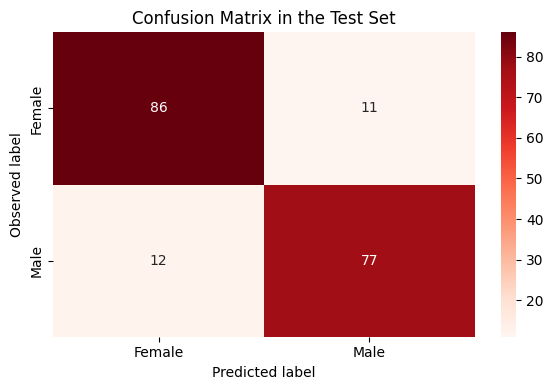

In [25]:
# Plot the confusion matrix

import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Reds",
    xticklabels=["Female", "Male"],
    yticklabels=["Female", "Male"]
)
plt.title("Confusion Matrix in the Test Set")
plt.xlabel("Predicted label")
plt.ylabel("Observed label")
plt.tight_layout()
plt.show()

**Figure 1.** Confusion matrix for the held-out test set. Rows represent observed class labels and columns represent predicted class labels.

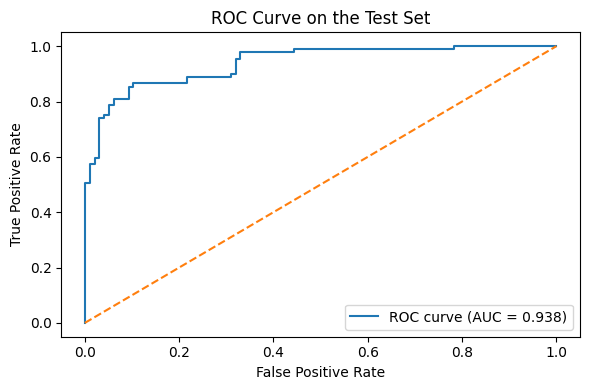

In [26]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
test_auc = roc_auc_score(y_test, y_test_proba)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {test_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve on the Test Set")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

**Figure 2.** Receiver operating characteristic (ROC) curve for the held-out test set. The area under the curve (AUC) summarizes discrimination performance across thresholds.

### Feature importance and effect size analysis

Feature importance is assessed using standardized logistic regression coefficients, which reflect the contribution of each feature within the multivariate model.

Univariate effect sizes (Cohen’s d) are computed to quantify the magnitude of differences between male and female participants for each structural measure. Cohen’s d is computed as the difference between male and female values. Positive values indicate larger values in male participants, whereas negative values indicate larger values in female participants.

Comparing these two measures allows assessment of how multivariate importance relates to univariate group differences.

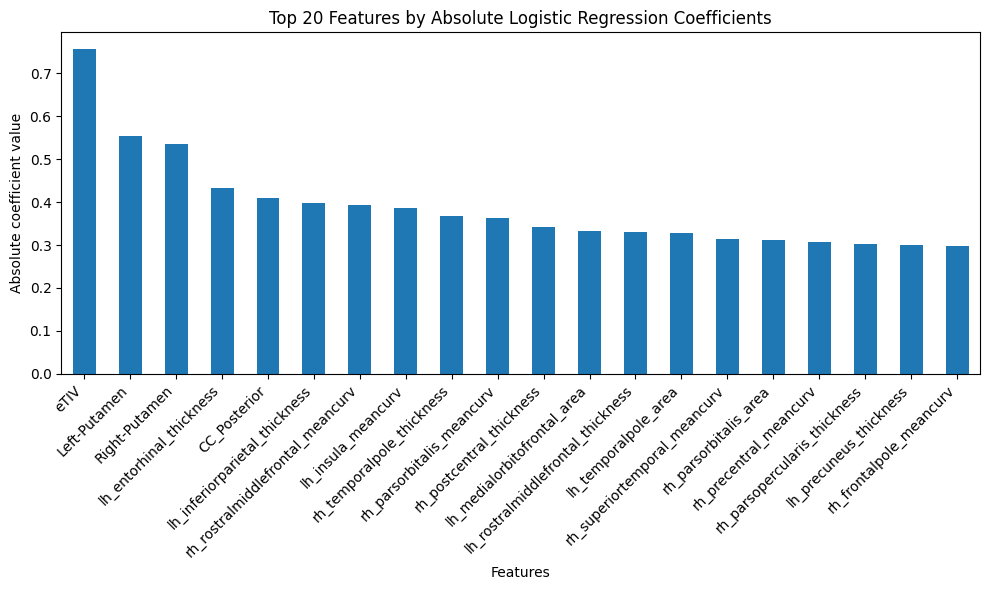

In [12]:
# Extract coefficients from the logistic regression model inside the pipeline
coefficients = best_model.named_steps["model"].coef_[0]

feature_importance = pd.Series(coefficients, index=feature_cols)

top_features = feature_importance.abs().sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 6))
top_features.plot(kind="bar")
plt.title("Top 20 Features by Absolute Logistic Regression Coefficients")
plt.ylabel("Absolute coefficient value")
plt.xlabel("Features")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Figure 3.** Top 20 structural brain features ranked by the absolute magnitude of their standardized logistic regression coefficients. Larger absolute coefficients indicate a stronger conditional contribution to classification within the multivariate model.

In [13]:
import numpy as np

# Create a full analysis dataframe for group comparisons
analysis_df = data_df.copy()


def cohens_d(x1, x2):
    n1, n2 = len(x1), len(x2)
    s1, s2 = x1.std(ddof=1), x2.std(ddof=1)
    pooled_sd = np.sqrt(((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / (n1 + n2 - 2))
    if pooled_sd == 0:
      return 0

    return (x1.mean() - x2.mean()) / pooled_sd


effect_sizes = []
for col in feature_cols:
    male_vals = analysis_df.loc[analysis_df["sex"] == "male", col]
    female_vals = analysis_df.loc[analysis_df["sex"] == "female", col]
    d = cohens_d(male_vals, female_vals)
    effect_sizes.append({"feature": col, "cohens_d": d, "abs_d": abs(d)})

effect_sizes_df = pd.DataFrame(effect_sizes).sort_values("abs_d", ascending=False)

effect_sizes_df.head(20)

,feature,cohens_d,abs_d
0,eTIV,1.670173,1.670173
8,lh_inferiortemporal_area,1.108188,1.108188
237,rh_rostralmiddlefrontal_area,1.107667,1.107667
221,rh_lateraloccipital_area,1.097866,1.097866
10,lh_lateraloccipital_area,1.087752,1.087752
23,lh_precentral_area,1.083393,1.083393
219,rh_inferiortemporal_area,1.064451,1.064451
234,rh_precentral_area,1.059854,1.059854
26,lh_rostralmiddlefrontal_area,1.058751,1.058751
217,rh_fusiform_area,1.050464,1.050464


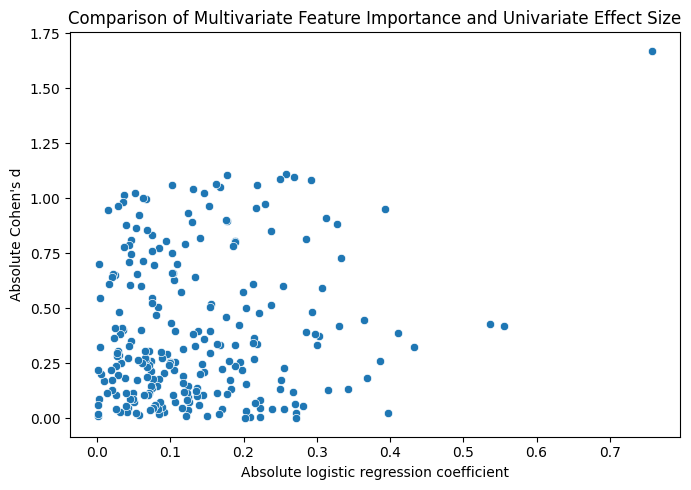

In [14]:
coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": coefficients,
    "abs_coefficient": np.abs(coefficients)
})

comparison_df = pd.merge(coef_df, effect_sizes_df, on="feature")
comparison_df = comparison_df.sort_values("abs_coefficient", ascending=False)

plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=comparison_df,
    x="abs_coefficient",
    y="abs_d"
)
plt.xlabel("Absolute logistic regression coefficient")
plt.ylabel("Absolute Cohen's d")
plt.title("Comparison of Multivariate Feature Importance and Univariate Effect Size")
plt.tight_layout()
plt.show()

**Figure 4.** Relationship between multivariate feature importance (logistic regression coefficients) and univariate effect sizes (Cohen’s d) across structural brain measures. Features with large univariate group differences do not necessarily have the largest conditional contribution in the multivariate classifier.

### Distribution overlap for selected structural measures

To characterize overlap between groups, distributions are visualized for a small number of selected structural measures. This helps illustrate that even features contributing strongly to classification may still show substantial overlap between male and female participants.

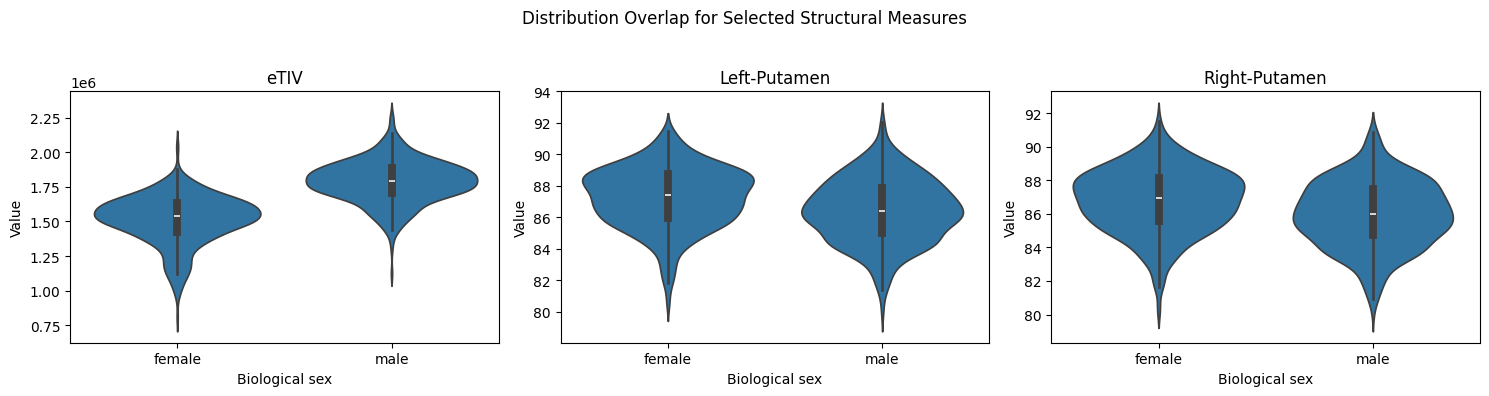

In [15]:
selected_features = top_features.index[:3].tolist()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, feature in zip(axes, selected_features):
    sns.violinplot(data=analysis_df, x="sex", y=feature, ax=ax, inner="box")
    ax.set_title(feature)
    ax.set_xlabel("Biological sex")
    ax.set_ylabel("Value")

plt.suptitle("Distribution Overlap for Selected Structural Measures")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

**Figure 5.** Distribution overlap between male and female participants for three selected structural measures. Although group differences are visible, the distributions still overlap substantially.

### Sensitivity analysis: controlling for global brain size

To assess whether classification performance is driven by global brain size differences, a second model is estimated including estimated total intracranial volume (eTIV) as an additional predictor.

In [18]:
# Sensitivity analysis: include eTIV

# Check that eTIV exists
assert "eTIV" in data_df.columns, "eTIV column not found in dataset"

# Create a second dataset including eTIV
X_with_tiv = X.copy()
X_with_tiv["eTIV"] = data_df["EstimatedTotalIntraCranialVol"]
[c for c in data_df.columns if "tiv" in c.lower() or "cranial" in c.lower()]

# Train-test split (same settings as main model)
X_train_tiv, X_test_tiv, y_train_tiv, y_test_tiv = train_test_split(
    X_with_tiv,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Grid search with cross-validation
grid_search_tiv = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="roc_auc",
    return_train_score=True
)

grid_search_tiv.fit(X_train_tiv, y_train_tiv)

# Best model
best_model_tiv = grid_search_tiv.best_estimator_

# Predictions
y_test_pred_tiv = best_model_tiv.predict(X_test_tiv)
y_test_proba_tiv = best_model_tiv.predict_proba(X_test_tiv)[:, 1]

# Evaluation
test_auc_tiv = roc_auc_score(y_test_tiv, y_test_proba_tiv)
bal_acc_tiv = balanced_accuracy_score(y_test_tiv, y_test_pred_tiv)

print("Best CV ROC-AUC with eTIV:", grid_search_tiv.best_score_)
print("Test ROC-AUC with eTIV:", test_auc_tiv)
print("Balanced accuracy with eTIV:", bal_acc_tiv)
print("Confusion matrix with eTIV:")
print(confusion_matrix(y_test_tiv, y_test_pred_tiv))


AttributeError: 'numpy.ndarray' object has no attribute 'index'

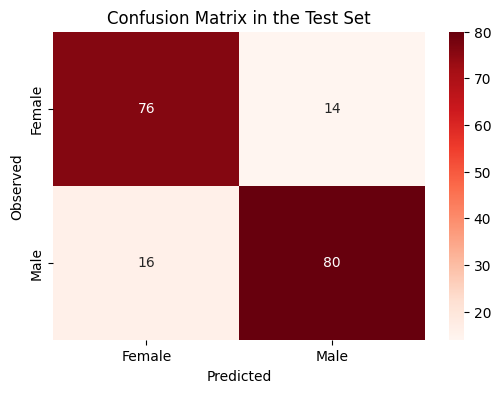

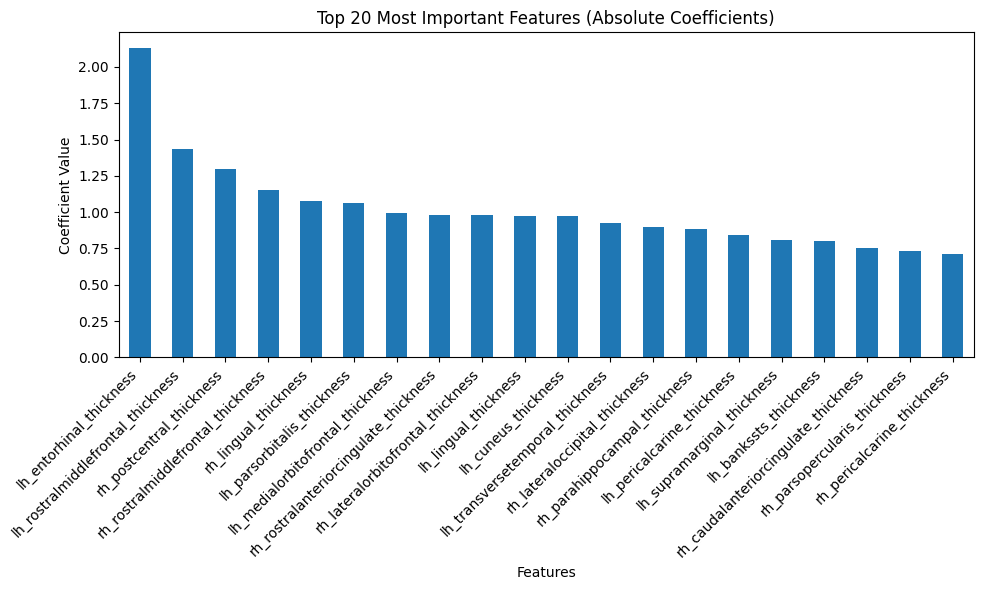

In [ ]:
# Plot the confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=['Female', 'Male'], yticklabels=['Female', 'Male'])
plt.title('Confusion Matrix in the Test Set')
plt.xlabel('Predicted')
plt.ylabel('Observed')

# Plot the 20 most important features based on the absolute coefficients of the logistic regression model
feature_importance = pd.Series(best_model.coef_[0], index=data_df.columns[3:])
plt.figure(figsize=(10, 6))
feature_importance.abs().sort_values(ascending=False).head(20).plot(kind='bar')
plt.title("Top 20 Features by Absolute Logistic Regression Coefficients")
plt.ylabel('Coefficient Value')
plt.xlabel('Features')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 3. Interpretation and Reflection (50%)

Interpretation (~400-500 words):
- What is your classification accuracy? Is this high or low, and compared to what?
- Which brain measures show the largest sex differences?
- How much overlap exists between groups? What proportion of variance is explained by sex?
- What do your results suggest about structural sex differences in the brain?

Reflection (~600-800 words):
- What challenges did you encounter during implementation?
- How did your final analysis differ from your proposal, if at all?
- What are the main limitations of your approach?
- What did this project teach you about neuroimaging analysis?

*You can write your interpretation and reflection in this markdown cell. Feel free to structure it with subheadings, bullet points using Markdown (e.g., **bold**, *italic*, `code`). You can look up the syntax for Markdown here: https://www.markdownguide.org/basic-syntax/.*